In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
import numpy as np

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
data = load_breast_cancer()
X = StandardScaler().fit_transform(data.data)
y = data.target
# Use only benign (class 1) for training the autoencoder to model "normal"
X_train = X[y == 1]
X_train_t = torch.FloatTensor(X_train).to(device)
X_all_t = torch.FloatTensor(X).to(device)

In [3]:
class AnomalyDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Linear(30, 8)
        self.decoder = nn.Linear(8, 30)
    def forward(self, x):
        return self.decoder(torch.relu(self.encoder(x)))

In [4]:
model = AnomalyDetector().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
for epoch in range(100):
    optimizer.zero_grad()
    out = model(X_train_t)
    loss = criterion(out, X_train_t)
    loss.backward()
    optimizer.step()

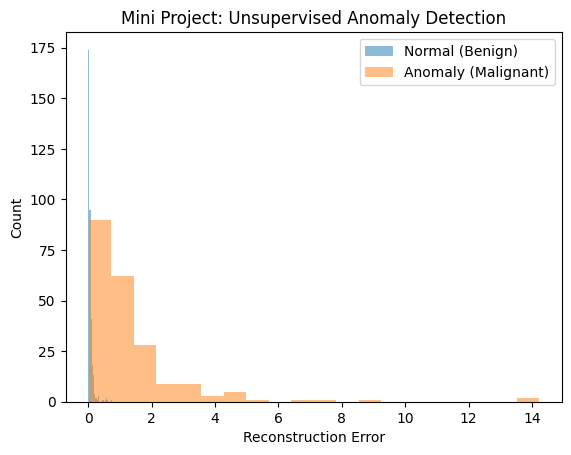

In [5]:
with torch.no_grad():
    recon = model(X_all_t)
    mse = torch.mean((recon - X_all_t)**2, dim=1).cpu().numpy()
plt.hist(mse[y == 1], bins=20, alpha=0.5, label='Normal (Benign)')
plt.hist(mse[y == 0], bins=20, alpha=0.5, label='Anomaly (Malignant)')
plt.xlabel('Reconstruction Error')
plt.ylabel('Count')
plt.legend()
plt.title('Mini Project: Unsupervised Anomaly Detection')
plt.savefig('mini_project_results.png')